In [24]:
import feedparser
import pandas as pd
import time
import requests
import os
print("tout est good")

tout est good


In [4]:

# Configuration
nom_fichier = "bulletins_anssi_avec_cves.csv"
url_avis = "https://www.cert.ssi.gouv.fr/avis/feed/"
url_alertes = "https://www.cert.ssi.gouv.fr/alerte/feed/"

# --- BLOC 2 : FONCTIONS ---
def extraire_flux_rss(url, type_bulletin):
    flux = feedparser.parse(url)
    liste_bulletins = []
    for entry in flux.entries:
        liste_bulletins.append({
            "id_anssi": entry.link.strip("/").split("/")[-1],
            "titre": entry.title,
            "description": entry.description,
            "date_publication": entry.published,
            "lien": entry.link,
            "type_bulletin": type_bulletin
        })
    time.sleep(1)
    return liste_bulletins


In [5]:
def extraire_cves_du_bulletin(lien_bulletin):
    url_json = f"{lien_bulletin.strip('/')}/json/"
    try:
        response = requests.get(url_json)
        if response.status_code == 200:
            data = response.json()
            return [item['name'] for item in data.get("cves", [])]
        return []
    except Exception as e:
        print(f"Erreur pour {lien_bulletin}: {e}")
        return []

In [6]:
def mettre_a_jour_donnees(nom_fichier, url_avis, url_alertes):
    print("Récupération des flux...")
    avis = extraire_flux_rss(url_avis, "Avis")
    alertes = extraire_flux_rss(url_alertes, "Alerte")
    df_flux_actuel = pd.DataFrame(avis + alertes)
    df_flux_actuel['id_anssi'] = df_flux_actuel['id_anssi'].astype(str).str.strip()

    if os.path.exists(nom_fichier):
        df_existant = pd.read_csv(nom_fichier)
        df_existant['id_anssi'] = df_existant['id_anssi'].astype(str).str.strip()
        
        # On cherche ce qui est dans le flux mais PAS dans le CSV
        mask = ~df_flux_actuel['id_anssi'].isin(df_existant['id_anssi'])
        nouveaux_items = df_flux_actuel[mask].copy()
        
        if not nouveaux_items.empty:
            print(f"{len(nouveaux_items)} manquants détectés. Extraction des CVE...")
            nouveaux_items['liste_cves'] = nouveaux_items['lien'].apply(extraire_cves_du_bulletin)
            df_final = pd.concat([df_existant, nouveaux_items], ignore_index=True)
            df_final = df_final.drop_duplicates(subset=['id_anssi'])
            df_final.to_csv(nom_fichier, index=False, encoding="utf-8-sig")
            print(f"Mise à jour réussie. Total : {len(df_final)}")
        else:
            print("Aucun nouveau bulletin à ajouter.")
            df_final = df_existant
    else:
        print("Fichier inexistant, création complète du CSV...")
        df_flux_actuel['liste_cves'] = df_flux_actuel['lien'].apply(extraire_cves_du_bulletin)
        df_final = df_flux_actuel.drop_duplicates(subset=['id_anssi'])
        df_final.to_csv(nom_fichier, index=False, encoding="utf-8-sig")

    print(f"Nombre total de bulletins dans le CSV : {len(df_final)}")
    display(df_final.tail())
    return df_final

In [7]:
df_final = mettre_a_jour_donnees(nom_fichier, url_avis, url_alertes)

Récupération des flux...
Fichier inexistant, création complète du CSV...
Nombre total de bulletins dans le CSV : 80


,id_anssi,titre,description,date_publication,lien,type_bulletin,liste_cves
75,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,[Mise à jour du 09 février 2026] Le 6 février ...,"Fri, 30 Jan 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"[CVE-2026-1340, CVE-2026-1281]"
76,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN...,Une vulnérabilité a été découverte dans Cisco ...,"Wed, 25 Feb 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"[CVE-2026-20127, CVE-2022-20775]"
77,CERTFR-2026-ALE-003,Note d’alerte – Ciblage des messageries instan...,Les travaux conjoints des services membres du ...,"Fri, 20 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[]
78,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,"Le 15 octobre 2025, F5 a publié un avis de séc...","Tue, 31 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[CVE-2025-53521]
79,CERTFR-2026-ALE-005,[Màj] Vulnérabilité dans Microsoft Exchange Se...,"[Mise à jour du 11 juin 2026] Le 9 juin 2026, ...","Fri, 15 May 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[CVE-2026-42897]


In [8]:

print("Aperçu :")
display(df_final.head())


Aperçu :


,id_anssi,titre,description,date_publication,lien,type_bulletin,liste_cves
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...,Une vulnérabilité a été découverte dans Cisco ...,"Fri, 05 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,[CVE-2026-20245]
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,De multiples vulnérabilités ont été découverte...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,"[CVE-2026-50752, CVE-2026-50751]"
2,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication ...,Une vulnérabilité a été découverte dans Veeam ...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,[CVE-2026-44963]
3,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Une vulnérabilité a été découverte dans les pr...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,[CVE-2026-8045]
4,CERTFR-2026-AVI-0714,Multiples vulnérabilités dans les produits Sie...,De multiples vulnérabilités ont été découverte...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,"[CVE-2025-15467, CVE-2026-24349, CVE-2025-40808]"


In [9]:
# Test pour vérifier le update

# 1. On supprime les 5 dernières lignes pour simuler un fichier incomplet
if os.path.exists(nom_fichier):
    df_test = pd.read_csv(nom_fichier)
    taille_avant = len(df_test)
    df_test = df_test.iloc[:-5] 
    df_test.to_csv(nom_fichier, index=False, encoding="utf-8-sig")
    print(f"Test : {taille_avant} -> {len(df_test)} lignes. (Les 5 dernières supprimées)")
    display(df_test.tail(7))
    
    # 2. On lance la mise à jour pour réparer le fichier
    print("\n--- Lancement de la mise à jour (Réparation) ---")
    df_final = mettre_a_jour_donnees(nom_fichier, url_avis, url_alertes)
    
    # 3. Vérification finale
    print("\n--- Vérification finale des données ---")
    print(f"Taille finale après update : {len(df_final)} lignes.")
    print("Voici les dernières lignes (les 5 que nous avions supprimées doivent être revenues) :")
    display(df_final.tail(7))
else:
    print("Fichier introuvable, impossible de réaliser le test.")

Test : 80 -> 75 lignes. (Les 5 dernières supprimées)


,id_anssi,titre,description,date_publication,lien,type_bulletin,liste_cves
68,CERTFR-2025-ALE-008,[MàJ] Vulnérabilité dans Roundcube (05 juin 2025),[Mise à jour du 06 juin 2025] Une preuve de co...,"Thu, 05 Jun 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,['CVE-2025-49113']
69,CERTFR-2025-ALE-009,Multiples vulnérabilités dans Citrix NetScaler...,**[Mise à jour du 17 juillet 2025]** L'éditeur...,"Tue, 01 Jul 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-6543', 'CVE-2025-5777']"
70,CERTFR-2025-ALE-010,[MàJ] Multiples vulnérabilités dans Microsoft ...,**[Mise à jour du 23 juillet 2025]** Le 20 jui...,"Mon, 21 Jul 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-53770', 'CVE-2025-53771']"
71,CERTFR-2025-ALE-011,Incidents de sécurité dans les pare-feux Sonic...,"[Mise à jour du 7 août 2025] Le 6 août 2025, S...","Tue, 05 Aug 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[]
72,CERTFR-2025-ALE-012,Vulnérabilité dans Citrix NetScaler ADC et Net...,"Le 26 août 2025, Citrix a publié un bulletin d...","Tue, 26 Aug 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,['CVE-2025-7775']
73,CERTFR-2025-ALE-013,[MàJ] Multiples vulnérabilités dans Cisco ASA ...,**[Mise à jour du 07 novembre 2025]** Le 5 nov...,"Thu, 25 Sep 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-20333', 'CVE-2025-20362']"
74,CERTFR-2025-ALE-014,[MàJ] Vulnérabilité dans React Server Componen...,**[Mise à jour du 11 décembre 2025]** Le CERT-...,"Fri, 05 Dec 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-55182', 'CVE-2025-66478']"



--- Lancement de la mise à jour (Réparation) ---
Récupération des flux...
5 manquants détectés. Extraction des CVE...
Mise à jour réussie. Total : 80
Nombre total de bulletins dans le CSV : 80


,id_anssi,titre,description,date_publication,lien,type_bulletin,liste_cves
75,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,[Mise à jour du 09 février 2026] Le 6 février ...,"Fri, 30 Jan 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"[CVE-2026-1340, CVE-2026-1281]"
76,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN...,Une vulnérabilité a été découverte dans Cisco ...,"Wed, 25 Feb 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"[CVE-2026-20127, CVE-2022-20775]"
77,CERTFR-2026-ALE-003,Note d’alerte – Ciblage des messageries instan...,Les travaux conjoints des services membres du ...,"Fri, 20 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[]
78,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,"Le 15 octobre 2025, F5 a publié un avis de séc...","Tue, 31 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[CVE-2025-53521]
79,CERTFR-2026-ALE-005,[Màj] Vulnérabilité dans Microsoft Exchange Se...,"[Mise à jour du 11 juin 2026] Le 9 juin 2026, ...","Fri, 15 May 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[CVE-2026-42897]



--- Vérification finale des données ---
Taille finale après update : 80 lignes.
Voici les dernières lignes (les 5 que nous avions supprimées doivent être revenues) :


,id_anssi,titre,description,date_publication,lien,type_bulletin,liste_cves
73,CERTFR-2025-ALE-013,[MàJ] Multiples vulnérabilités dans Cisco ASA ...,**[Mise à jour du 07 novembre 2025]** Le 5 nov...,"Thu, 25 Sep 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-20333', 'CVE-2025-20362']"
74,CERTFR-2025-ALE-014,[MàJ] Vulnérabilité dans React Server Componen...,**[Mise à jour du 11 décembre 2025]** Le CERT-...,"Fri, 05 Dec 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-55182', 'CVE-2025-66478']"
75,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,[Mise à jour du 09 février 2026] Le 6 février ...,"Fri, 30 Jan 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"[CVE-2026-1340, CVE-2026-1281]"
76,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN...,Une vulnérabilité a été découverte dans Cisco ...,"Wed, 25 Feb 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"[CVE-2026-20127, CVE-2022-20775]"
77,CERTFR-2026-ALE-003,Note d’alerte – Ciblage des messageries instan...,Les travaux conjoints des services membres du ...,"Fri, 20 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[]
78,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,"Le 15 octobre 2025, F5 a publié un avis de séc...","Tue, 31 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[CVE-2025-53521]
79,CERTFR-2026-ALE-005,[Màj] Vulnérabilité dans Microsoft Exchange Se...,"[Mise à jour du 11 juin 2026] Le 9 juin 2026, ...","Fri, 15 May 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[CVE-2026-42897]


Etape 3 Enrichissement des CVE


In [12]:

import ast

df_final["liste_cves"] = df_final["liste_cves"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
#pour transformer liste_cves en une ligne par CVE
df_cves = df_final.explode("liste_cves")
df_cves = df_cves.rename(columns={"liste_cves": "cve"})
df_cves = df_cves[df_cves["cve"].notna()]
df_cves = df_cves[df_cves["cve"] != ""]

display(df_cves.head())
print(df_cves.shape)

,id_anssi,titre,description,date_publication,lien,type_bulletin,cve
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...,Une vulnérabilité a été découverte dans Cisco ...,"Fri, 05 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,CVE-2026-20245
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,De multiples vulnérabilités ont été découverte...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,CVE-2026-50752
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,De multiples vulnérabilités ont été découverte...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,CVE-2026-50751
2,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication ...,Une vulnérabilité a été découverte dans Veeam ...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,CVE-2026-44963
3,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Une vulnérabilité a été découverte dans les pr...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,CVE-2026-8045


(1344, 7)


In [13]:
#enrichissement MITRE sur une seule CVE
def enrichir_cve_mitre(cve_id):
    url = f"https://cveawg.mitre.org/api/cve/{cve_id}"

    try:
        response = requests.get(url, timeout=10)

        if response.status_code != 200:
            return None

        data = response.json()

        resultat = {
            "description_cve": None,
            "cvss": None,
            "cwe": None,
            "cwe_description": None,
            "vendor": None,
            "produit": None,
            "versions_affectees": None
        }

        try:
            resultat["description_cve"] = data["containers"]["cna"]["descriptions"][0]["value"]
        except:
            pass

        try:
            metrics = data["containers"]["cna"]["metrics"][0]
            if "cvssV3_1" in metrics:
                resultat["cvss"] = metrics["cvssV3_1"]["baseScore"]
            elif "cvssV3_0" in metrics:
                resultat["cvss"] = metrics["cvssV3_0"]["baseScore"]
        except:
            pass

        try:
            problem = data["containers"]["cna"]["problemTypes"][0]["descriptions"][0]
            resultat["cwe"] = problem.get("cweId")
            resultat["cwe_description"] = problem.get("description")
        except:
            pass

        try:
            affected = data["containers"]["cna"]["affected"][0]
            resultat["vendor"] = affected.get("vendor")
            resultat["produit"] = affected.get("product")
            versions = [
                v.get("version")
                for v in affected.get("versions", [])
                if v.get("status") == "affected"
            ]
            resultat["versions_affectees"] = ", ".join(versions)
        except:
            pass

        return resultat

    except Exception as e:
        print(f"Erreur pour {cve_id} :", e)
        return None
    
#test    
test = enrichir_cve_mitre(df_cves["cve"].iloc[0])
print(test)


{'description_cve': 'A vulnerability in the CLI of Cisco Catalyst SD-WAN Controller, formerly SD-WAN vSmart, Cisco Catalyst SD-WAN Manager, formerly SD-WAN vManage, and Cisco Catalyst SD-WAN Validator, formerly SD-WAN vBond, could allow an authenticated, local attacker to execute arbitrary commands as root by supplying a crafted file to the affected system.\r\n\r\nThis vulnerability is due to insufficient validation of user-supplied input. An attacker could exploit this vulnerability by uploading a crafted file to the affected system. A successful exploit could allow the attacker to perform command injection attacks on an affected system and elevate their privileges as the root user.&nbsp;\r\nTo exploit this vulnerability, the attacker must have netadmin privileges on the affected system. This would require valid credentials or exploitation of  or . Cisco is not aware of successful exploitation by other methods. Cisco has observed limited cases where the exploitation of this bug result

In [14]:
#API EPSS
def enrichir_epss(cve_id):

    url = f"https://api.first.org/data/v1/epss?cve={cve_id}"

    try:
        response = requests.get(url, timeout=10)

        if response.status_code != 200:
            return None

        data = response.json()

        if len(data["data"]) > 0:
            return float(data["data"][0]["epss"])

        return None

    except Exception:
        return None
    

#test
epss_test = enrichir_epss(df_cves["cve"].iloc[0])
print(epss_test)

0.00356


In [15]:
#enrichissement complet d'une CVE
def enrichir_cve_complete(cve_id):

    mitre = enrichir_cve_mitre(cve_id)

    if mitre is None:
        return None

    mitre["epss"] = enrichir_epss(cve_id)

    return mitre

#test 
test_complet = enrichir_cve_complete(df_cves["cve"].iloc[0])

print(test_complet)


{'description_cve': 'A vulnerability in the CLI of Cisco Catalyst SD-WAN Controller, formerly SD-WAN vSmart, Cisco Catalyst SD-WAN Manager, formerly SD-WAN vManage, and Cisco Catalyst SD-WAN Validator, formerly SD-WAN vBond, could allow an authenticated, local attacker to execute arbitrary commands as root by supplying a crafted file to the affected system.\r\n\r\nThis vulnerability is due to insufficient validation of user-supplied input. An attacker could exploit this vulnerability by uploading a crafted file to the affected system. A successful exploit could allow the attacker to perform command injection attacks on an affected system and elevate their privileges as the root user.&nbsp;\r\nTo exploit this vulnerability, the attacker must have netadmin privileges on the affected system. This would require valid credentials or exploitation of  or . Cisco is not aware of successful exploitation by other methods. Cisco has observed limited cases where the exploitation of this bug result

In [16]:
#on teste sur 5 CVE seulement avant de lancer tout le dataset
resultats_test = []

for cve in df_cves["cve"].head(5):
    print("Enrichissement de :", cve)
    infos = enrichir_cve_complete(cve)
    resultats_test.append(infos)
    time.sleep(2)

df_test_enrichi = pd.DataFrame(resultats_test)

display(df_test_enrichi)

Enrichissement de : CVE-2026-20245
Enrichissement de : CVE-2026-50752
Enrichissement de : CVE-2026-50751
Enrichissement de : CVE-2026-44963
Enrichissement de : CVE-2026-8045


,description_cve,cvss,cwe,cwe_description,vendor,produit,versions_affectees,epss
0,A vulnerability in the CLI of Cisco Catalyst S...,7.8,CWE-116,Improper Encoding or Escaping of Output,Cisco,Cisco Catalyst SD-WAN Controller,"20.6.4, 20.9.2, 20.3.6, 20.7.2, 20.7.1, 20.5.1...",0.00356
1,A weakness in the certificate validation logic...,7.4,CWE-295,CWE-295: Improper Certificate Validation.,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82...",0.00031
2,A logic flow weakness in Remote Access and Mob...,NaN,CWE-287,CWE-287: Improper Authentication.,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82...",0.11841
3,A vulnerability allowing remote code execution...,NaN,CWE-502,CWE-502 Deserialization of Untrusted Data,Veeam,Backup and Replication,0,0.00586
4,CWE-611 Improper Restriction of XML External E...,NaN,CWE-611,CWE-611 Improper restriction of XML external e...,Schneider Electric,EcoStruxure™ IT Data Center Expert,v9.1.1 and Prior,0.00057


In [17]:
# Enrichissement complet sur toutes les CVE

df_travail = df_cves.copy()

liste_infos = []

for i, cve in enumerate(df_travail["cve"]):
    print(f"{i+1}/{len(df_travail)} : {cve}")

    infos = enrichir_cve_complete(cve)

    if infos is None:
        infos = {
            "description_cve": None,
            "cvss": None,
            "cwe": None,
            "cwe_description": None,
            "vendor": None,
            "produit": None,
            "versions_affectees": None,
            "epss": None
        }

    liste_infos.append(infos)

    time.sleep(2)  

df_infos = pd.DataFrame(liste_infos)

df_consolide = pd.concat(
    [
        df_travail.reset_index(drop=True),
        df_infos.reset_index(drop=True)
    ],
    axis=1
)

display(df_consolide.head())
print(df_consolide.shape)

df_consolide.to_csv(
    "donnees_anssi_cves_enrichies.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV enrichi généré : donnees_anssi_cves_enrichies.csv")

1/1344 : CVE-2026-20245
2/1344 : CVE-2026-50752
3/1344 : CVE-2026-50751
4/1344 : CVE-2026-44963
5/1344 : CVE-2026-8045
6/1344 : CVE-2025-15467
7/1344 : CVE-2026-24349
8/1344 : CVE-2025-40808
9/1344 : CVE-2026-44746
10/1344 : CVE-2026-44750
11/1344 : CVE-2026-44743
12/1344 : CVE-2026-44755
13/1344 : CVE-2026-44754
14/1344 : CVE-2026-29145
15/1344 : CVE-2026-44751
16/1344 : CVE-2026-44757
17/1344 : CVE-2026-27671
18/1344 : CVE-2026-44744
19/1344 : CVE-2026-44748
20/1344 : CVE-2025-68161
21/1344 : CVE-2026-24315
22/1344 : CVE-2026-22732
23/1344 : CVE-2026-40128
24/1344 : CVE-2026-34180
25/1344 : CVE-2026-35188
26/1344 : CVE-2026-42766
27/1344 : CVE-2026-9076
28/1344 : CVE-2026-34181
29/1344 : CVE-2026-42770
30/1344 : CVE-2026-45445
31/1344 : CVE-2026-7383
32/1344 : CVE-2026-42771
33/1344 : CVE-2026-42765
34/1344 : CVE-2026-42769
35/1344 : CVE-2026-45447
36/1344 : CVE-2026-45446
37/1344 : CVE-2026-34183
38/1344 : CVE-2026-42767
39/1344 : CVE-2026-42764
40/1344 : CVE-2026-42768
41/1344 : CV

,id_anssi,titre,description,date_publication,lien,type_bulletin,cve,description_cve,cvss,cwe,cwe_description,vendor,produit,versions_affectees,epss
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...,Une vulnérabilité a été découverte dans Cisco ...,"Fri, 05 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,CVE-2026-20245,A vulnerability in the CLI of Cisco Catalyst S...,7.8,CWE-116,Improper Encoding or Escaping of Output,Cisco,Cisco Catalyst SD-WAN Controller,"20.6.4, 20.9.2, 20.3.6, 20.7.2, 20.7.1, 20.5.1...",0.00356
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,De multiples vulnérabilités ont été découverte...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,CVE-2026-50752,A weakness in the certificate validation logic...,7.4,CWE-295,CWE-295: Improper Certificate Validation.,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82...",0.00031
2,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,De multiples vulnérabilités ont été découverte...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,CVE-2026-50751,A logic flow weakness in Remote Access and Mob...,NaN,CWE-287,CWE-287: Improper Authentication.,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82...",0.11841
3,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication ...,Une vulnérabilité a été découverte dans Veeam ...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,CVE-2026-44963,A vulnerability allowing remote code execution...,NaN,CWE-502,CWE-502 Deserialization of Untrusted Data,Veeam,Backup and Replication,0,0.00586
4,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Une vulnérabilité a été découverte dans les pr...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,CVE-2026-8045,CWE-611 Improper Restriction of XML External E...,NaN,CWE-611,CWE-611 Improper restriction of XML external e...,Schneider Electric,EcoStruxure™ IT Data Center Expert,v9.1.1 and Prior,0.00057


(1344, 15)
CSV enrichi généré : donnees_anssi_cves_enrichies.csv


PARTIE 4 consollidation des données

In [ ]:
def calculer_severite(cvss):
    if pd.isna(cvss):
        return "Non disponible"
    elif cvss < 4:
        return "Faible"
    elif cvss < 7:
        return "Moyenne"
    elif cvss < 9:
        return "Élevée"
    else:
        return "Critique"

df_consolide["cvss"] = pd.to_numeric(df_consolide["cvss"], errors="coerce")
df_consolide["epss"] = pd.to_numeric(df_consolide["epss"], errors="coerce")

df_consolide["base_severity"] = df_consolide["cvss"].apply(calculer_severite)

colonnes_finales = [
    "id_anssi",
    "titre",
    "type_bulletin",
    "date_publication",
    "cve",
    "cvss",
    "base_severity",
    "cwe",
    "cwe_description",
    "epss",
    "lien",
    "description_cve",
    "vendor",
    "produit",
    "versions_affectees"
]

df_final_consolide = df_consolide[colonnes_finales].copy()

display(df_final_consolide.head())
print(df_final_consolide.shape)

df_final_consolide.to_csv(
    "cve_consolide_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Fichier CSV final généré : cve_consolide_final.csv")

,id_anssi,titre,type_bulletin,date_publication,cve,cvss,base_severity,cwe,cwe_description,epss,lien,description_cve,vendor,produit,versions_affectees
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...,Avis,"Fri, 05 Jun 2026 00:00:00 +0000",CVE-2026-20245,7.8,Élevée,CWE-116,Improper Encoding or Escaping of Output,0.00356,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A vulnerability in the CLI of Cisco Catalyst S...,Cisco,Cisco Catalyst SD-WAN Controller,"20.6.4, 20.9.2, 20.3.6, 20.7.2, 20.7.1, 20.5.1..."
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,Avis,"Tue, 09 Jun 2026 00:00:00 +0000",CVE-2026-50752,7.4,Élevée,CWE-295,CWE-295: Improper Certificate Validation.,0.00031,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A weakness in the certificate validation logic...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
2,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,Avis,"Tue, 09 Jun 2026 00:00:00 +0000",CVE-2026-50751,NaN,Non disponible,CWE-287,CWE-287: Improper Authentication.,0.11841,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A logic flow weakness in Remote Access and Mob...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
3,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication ...,Avis,"Tue, 09 Jun 2026 00:00:00 +0000",CVE-2026-44963,NaN,Non disponible,CWE-502,CWE-502 Deserialization of Untrusted Data,0.00586,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A vulnerability allowing remote code execution...,Veeam,Backup and Replication,0
4,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Avis,"Tue, 09 Jun 2026 00:00:00 +0000",CVE-2026-8045,NaN,Non disponible,CWE-611,CWE-611 Improper restriction of XML external e...,0.00057,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,CWE-611 Improper Restriction of XML External E...,Schneider Electric,EcoStruxure™ IT Data Center Expert,v9.1.1 and Prior


(1344, 15)
Fichier CSV final généré : cve_consolide_final.csv


In [19]:
df_final_consolide.info()
df_final_consolide.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_anssi            1344 non-null   object 
 1   titre               1344 non-null   object 
 2   type_bulletin       1344 non-null   object 
 3   date_publication    1344 non-null   object 
 4   cve                 1344 non-null   object 
 5   cvss                543 non-null    float64
 6   base_severity       1344 non-null   object 
 7   cwe                 723 non-null    object 
 8   cwe_description     808 non-null    object 
 9   epss                1296 non-null   float64
 10  lien                1344 non-null   object 
 11  description_cve     1297 non-null   object 
 12  vendor              1295 non-null   object 
 13  produit             1295 non-null   object 
 14  versions_affectees  1297 non-null   object 
dtypes: float64(2), object(13)
memory usage: 157.6+ KB


,id_anssi,titre,type_bulletin,date_publication,cve,cvss,base_severity,cwe,cwe_description,epss,lien,description_cve,vendor,produit,versions_affectees
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...,Avis,"Fri, 05 Jun 2026 00:00:00 +0000",CVE-2026-20245,7.8,Élevée,CWE-116,Improper Encoding or Escaping of Output,0.00356,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A vulnerability in the CLI of Cisco Catalyst S...,Cisco,Cisco Catalyst SD-WAN Controller,"20.6.4, 20.9.2, 20.3.6, 20.7.2, 20.7.1, 20.5.1..."
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,Avis,"Tue, 09 Jun 2026 00:00:00 +0000",CVE-2026-50752,7.4,Élevée,CWE-295,CWE-295: Improper Certificate Validation.,0.00031,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A weakness in the certificate validation logic...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
2,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,Avis,"Tue, 09 Jun 2026 00:00:00 +0000",CVE-2026-50751,NaN,Non disponible,CWE-287,CWE-287: Improper Authentication.,0.11841,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A logic flow weakness in Remote Access and Mob...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
3,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication ...,Avis,"Tue, 09 Jun 2026 00:00:00 +0000",CVE-2026-44963,NaN,Non disponible,CWE-502,CWE-502 Deserialization of Untrusted Data,0.00586,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A vulnerability allowing remote code execution...,Veeam,Backup and Replication,0
4,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Avis,"Tue, 09 Jun 2026 00:00:00 +0000",CVE-2026-8045,NaN,Non disponible,CWE-611,CWE-611 Improper restriction of XML external e...,0.00057,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,CWE-611 Improper Restriction of XML External E...,Schneider Electric,EcoStruxure™ IT Data Center Expert,v9.1.1 and Prior


PARTIE 5

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

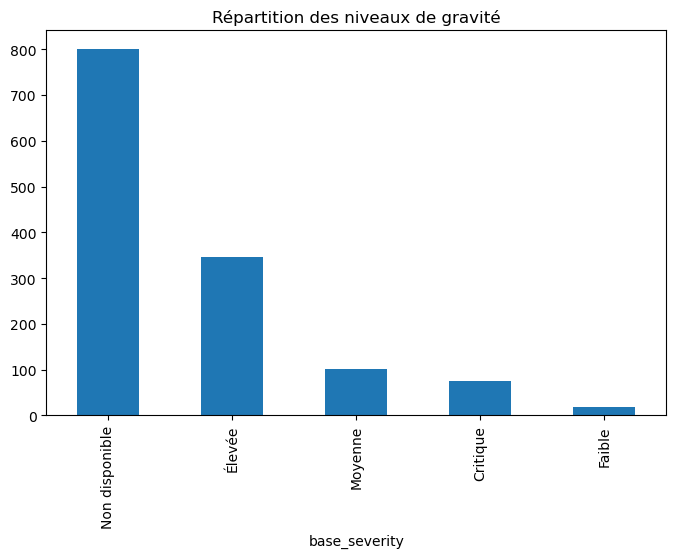

In [26]:
#Repartition des niveaux de gravité
plt.figure(figsize=(8,5))

df_final_consolide["base_severity"].value_counts().plot(kind="bar")

plt.title("Répartition des niveaux de gravité")
plt.show()


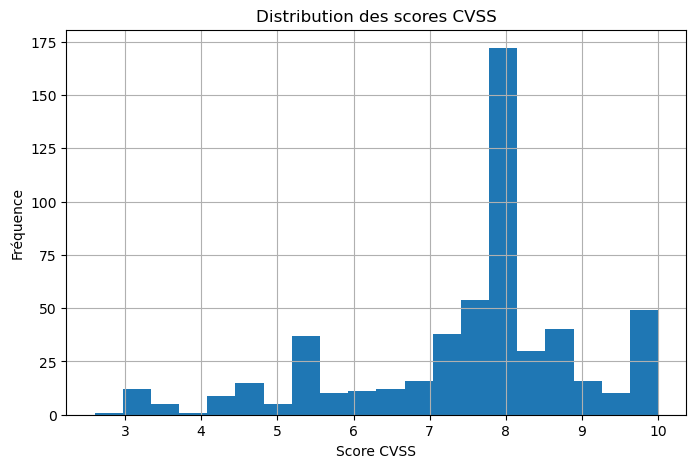

In [27]:
#Distribution des scores CVSS
plt.figure(figsize=(8,5))

df_final_consolide["cvss"].dropna().hist(
    bins=20
)

plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Fréquence")

plt.show()


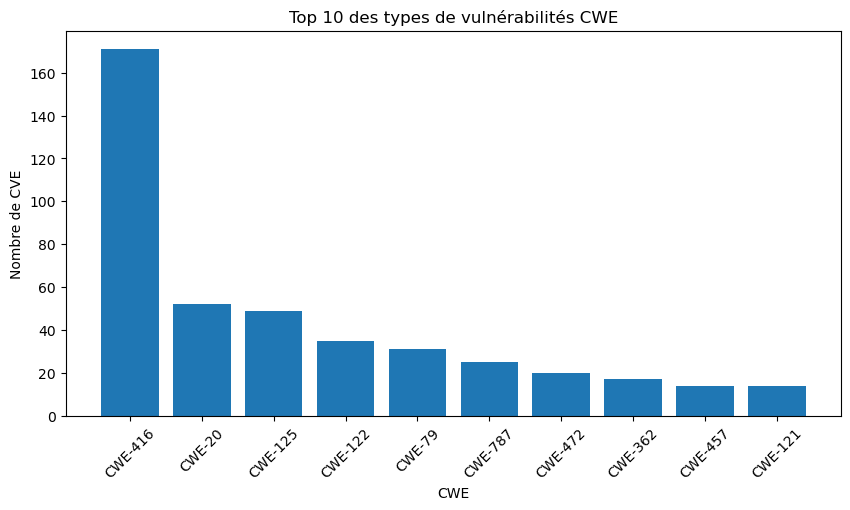

In [28]:
#top10 des CWE les plus frequents
top_cwe = (
    df_final_consolide["cwe"]
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(top_cwe.index, top_cwe.values)

plt.xticks(rotation=45)
plt.title("Top 10 des types de vulnérabilités CWE")
plt.xlabel("CWE")
plt.ylabel("Nombre de CVE")

plt.show()

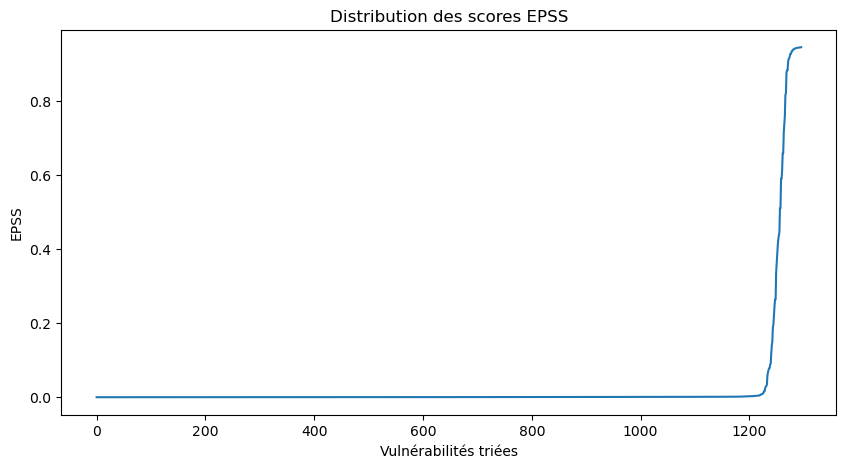

In [30]:
#Distribution des scores EPSS
plt.figure(figsize=(10,5))

epss_sorted = (
    df_final_consolide["epss"]
    .dropna()
    .sort_values()
)

plt.plot(epss_sorted.values)

plt.title("Distribution des scores EPSS")
plt.xlabel("Vulnérabilités triées")
plt.ylabel("EPSS")

plt.show()

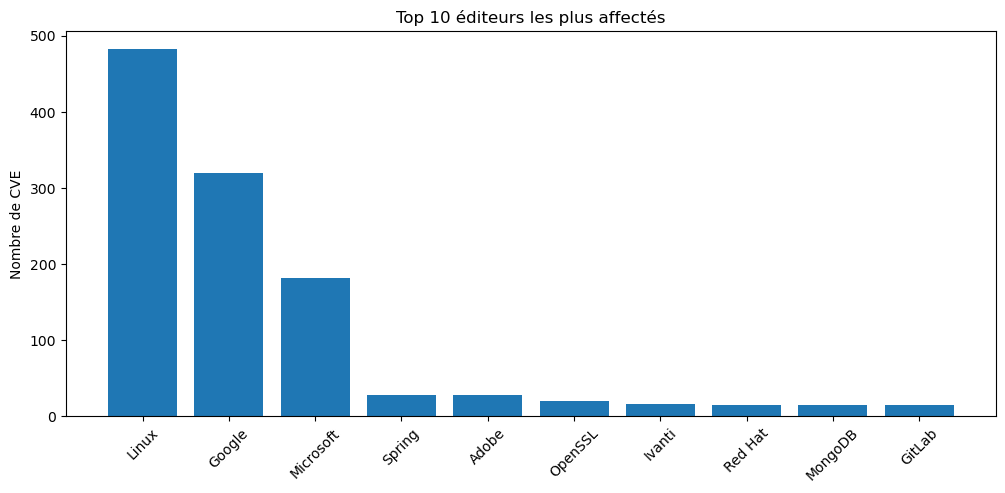

In [31]:
#Top 10 éditeurs affectés
top_vendor = (
    df_final_consolide["vendor"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

plt.bar(
    top_vendor.index,
    top_vendor.values
)

plt.xticks(rotation=45)

plt.title("Top 10 éditeurs les plus affectés")
plt.ylabel("Nombre de CVE")

plt.show()

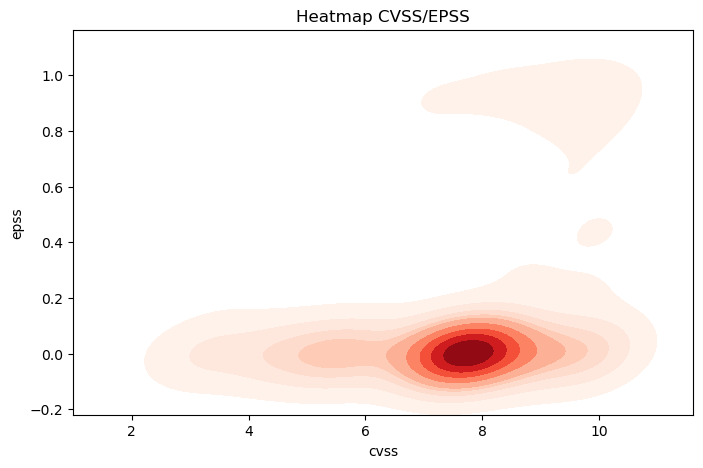

In [55]:
#Relation CVSS vs EPSS Heatmap 
plt.figure(figsize=(8, 5))
df_heat = df.dropna(subset=['cvss', 'epss'])
df_heat = df_heat[(df_heat['cvss'] > 0) & (df_heat['epss'] > 0)]  # retire les zéros
sns.kdeplot(x=df_heat['cvss'], y=df_heat['epss'], fill=True, cmap='Reds')
plt.title('Heatmap CVSS/EPSS')
plt.show()

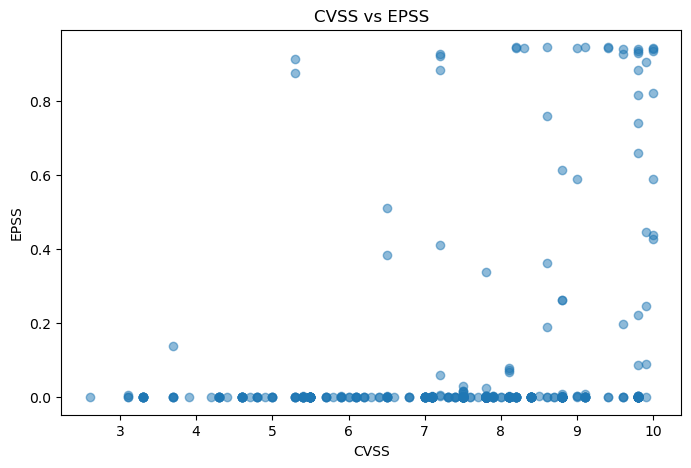

In [56]:
# Nuage de points CVSS vs EPSS ──
plt.figure(figsize=(8, 5))
plt.scatter(df['cvss'], df['epss'], alpha=0.5)
plt.title('CVSS vs EPSS'); plt.xlabel('CVSS'); plt.ylabel('EPSS')
plt.show()


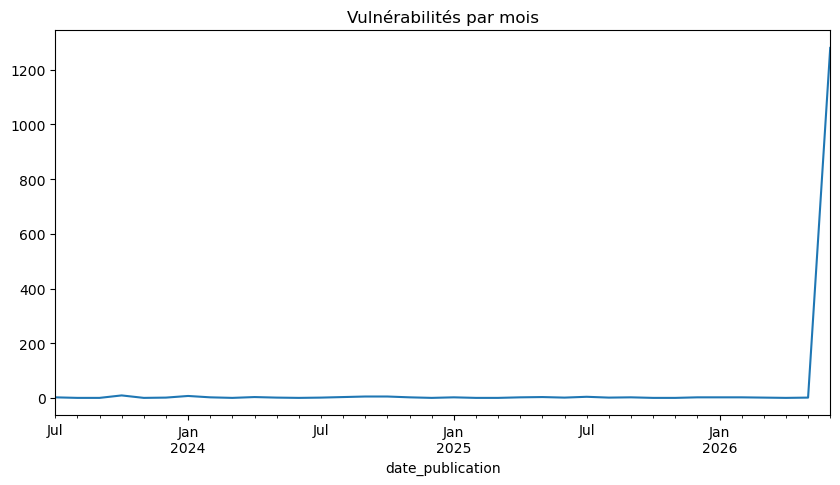

In [57]:
#Évolution temporelle des vulnérabilités
plt.figure(figsize=(10, 5))
df.set_index('date_publication').resample('ME').size().plot()
plt.title('Vulnérabilités par mois')
plt.show()


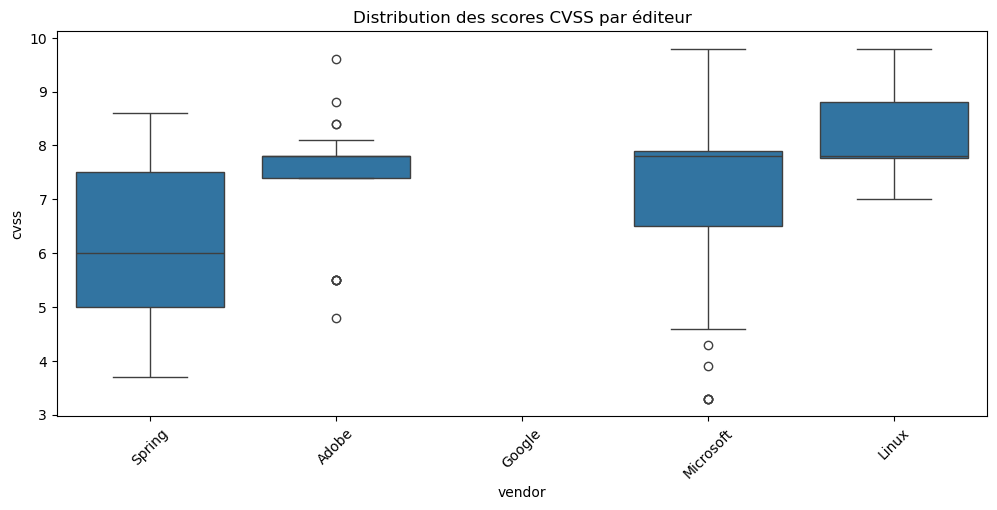

In [35]:
#Boxplot des scores CVSS par éditeur

top_vendor = (
    df_final_consolide["vendor"]
    .value_counts()
    .head(5)
    .index
)

df_box = df_final_consolide[
    df_final_consolide["vendor"].isin(top_vendor)
]

plt.figure(figsize=(12,5))

sns.boxplot(
    data=df_box,
    x="vendor",
    y="cvss"
)

plt.xticks(rotation=45)

plt.title("Distribution des scores CVSS par éditeur")

plt.show()

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = df_final_consolide.copy()
df['cvss'] = pd.to_numeric(df['cvss'], errors='coerce')
df['epss'] = pd.to_numeric(df['epss'], errors='coerce')
df['date_publication'] = pd.to_datetime(df['date_publication'], errors='coerce', utc=True)


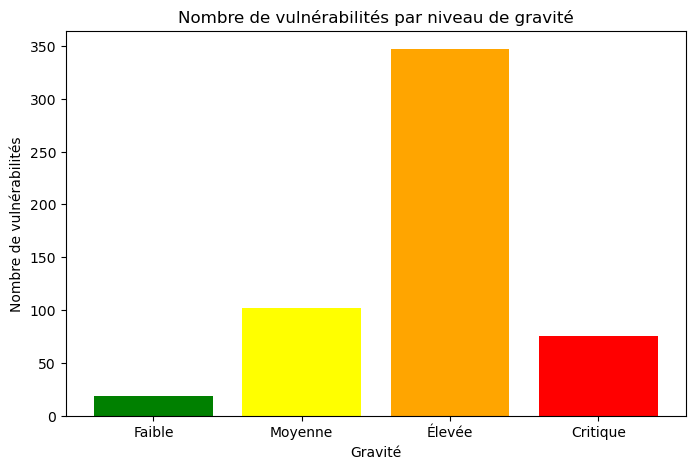

In [52]:
#Nombre de vulnérabilités par niveau de gravité ──
decompte_gravite = df['base_severity'].value_counts()
ordre = ['Faible', 'Moyenne', 'Élevée', 'Critique', 'Inconnu']
labels = [cat for cat in ordre if cat in decompte_gravite.index]
valeurs = [decompte_gravite[cat] for cat in labels]
couleurs = {'Non disponible': 'gray', 'Faible': 'green', 'Moyenne': 'yellow', 'Élevée': 'orange', 'Critique': 'red'}
plt.figure(figsize=(8, 5))
plt.bar(labels, valeurs, color=[couleurs[l] for l in labels])
plt.title('Nombre de vulnérabilités par niveau de gravité')
plt.xlabel('Gravité'); plt.ylabel('Nombre de vulnérabilités')
plt.show()


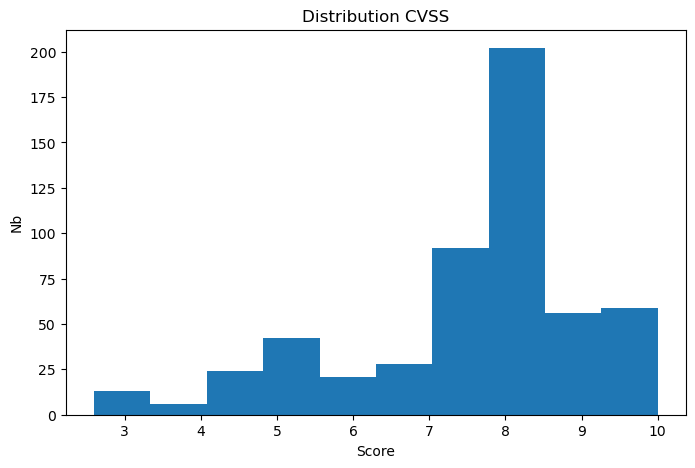

In [53]:
#Histogramme CVSS ──
plt.figure(figsize=(8, 5))
df['cvss'].hist(bins=10, grid=False)
plt.title('Distribution CVSS'); plt.xlabel('Score'); plt.ylabel('Nb')
plt.show()


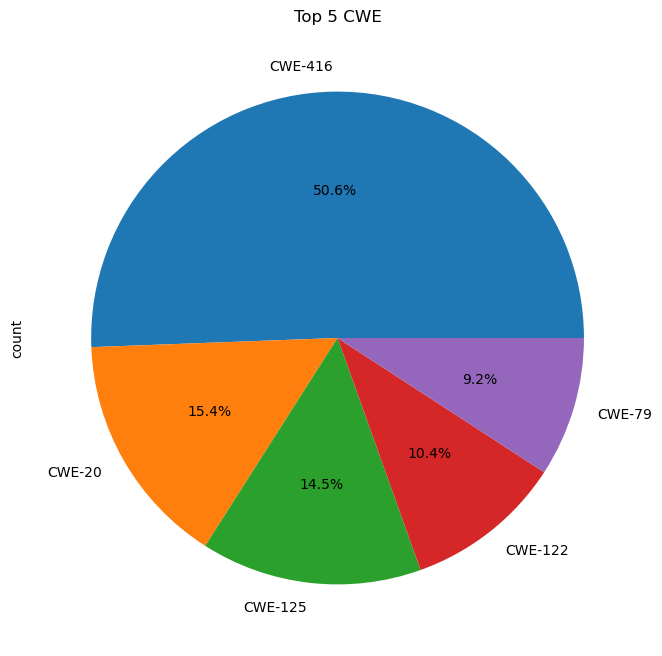

In [54]:
#Diagramme circulaire CWE ──
plt.figure(figsize=(8, 8))
df['cwe'].value_counts().head(5).plot.pie(autopct='%1.1f%%')
plt.title('Top 5 CWE')
plt.show()

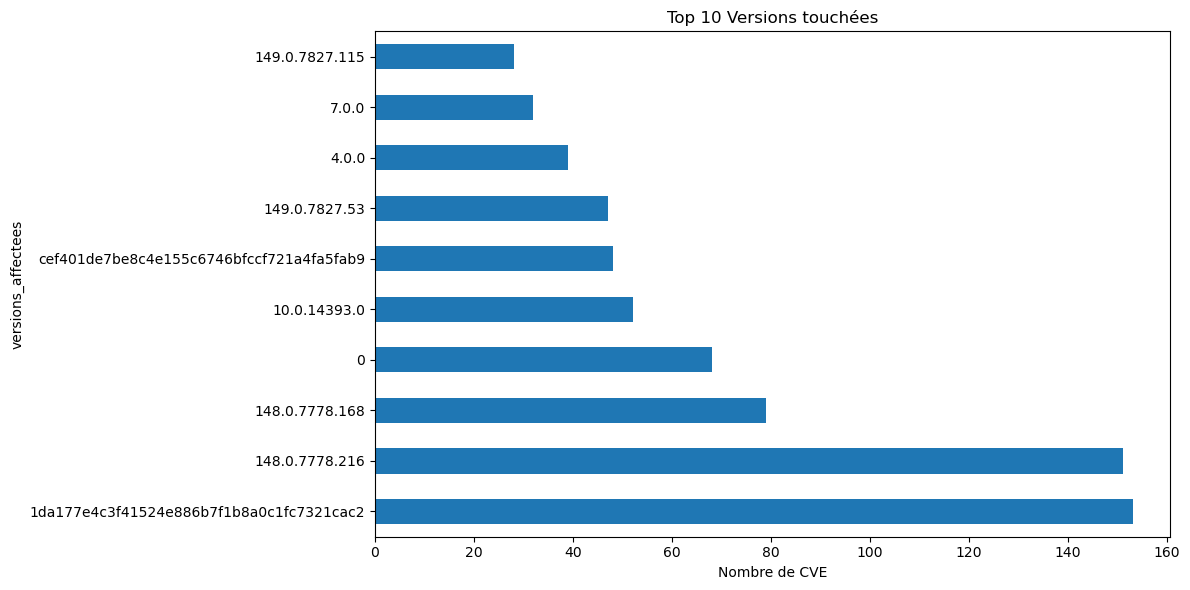

In [58]:
#  Versions les plus touchées ──
df_versions = df[df['versions_affectees'] != 'Non disponible']['versions_affectees']

# Éclater les versions séparées par des virgules
df_versions_split = df_versions.str.split(',').explode().str.strip()
df_versions_split = df_versions_split[df_versions_split != '']

plt.figure(figsize=(12, 6))
df_versions_split.value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Versions touchées')
plt.xlabel('Nombre de CVE')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

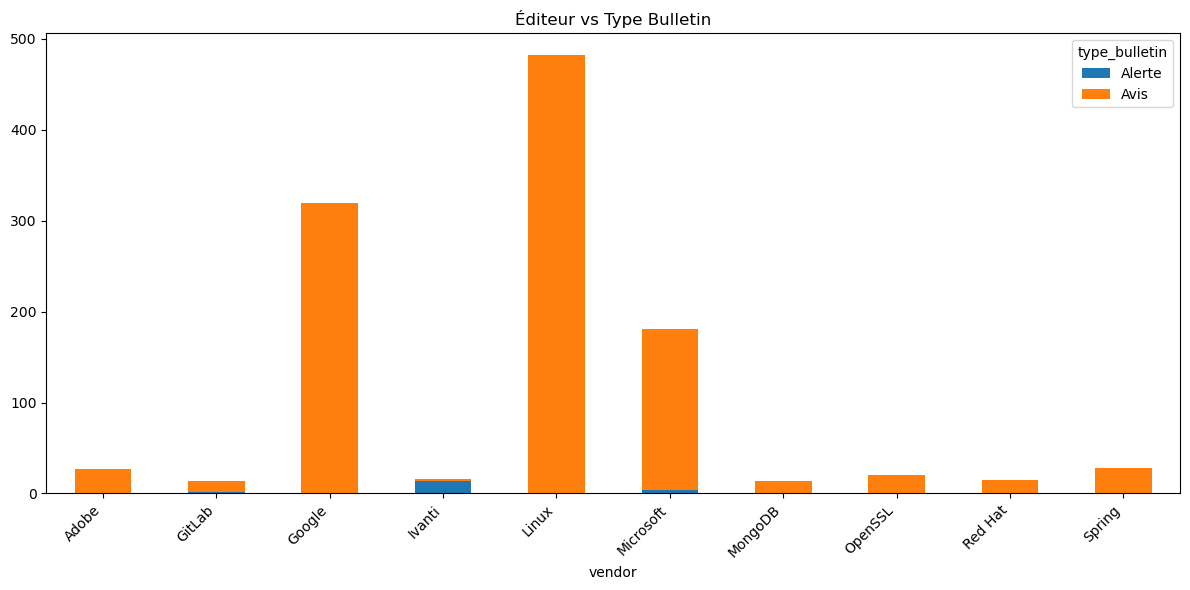

In [59]:
# Éditeur vs Type de bulletin ──
plt.figure(figsize=(12, 6))
top_ed = df[df['vendor'] != 'Non disponible']['vendor'].value_counts().head(10).index
df_top = df[df['vendor'].isin(top_ed)]
pd.crosstab(df_top['vendor'], df_top['type_bulletin']).plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.title('Éditeur vs Type Bulletin')
plt.tight_layout()
plt.show()

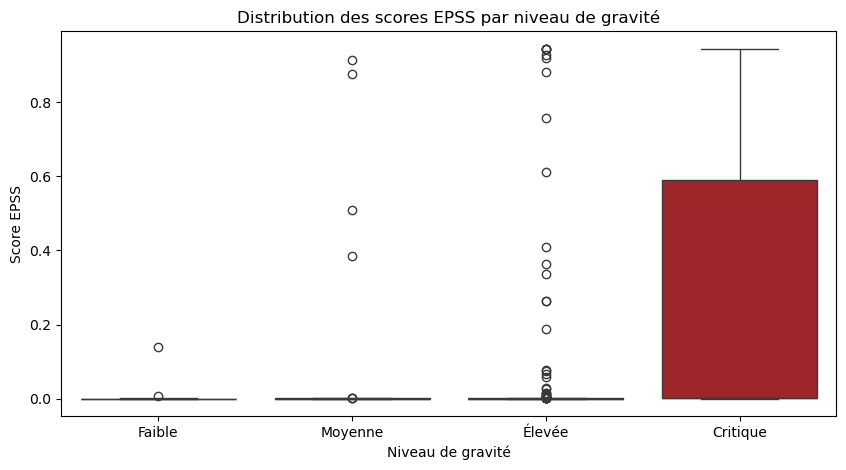

In [60]:
# Boxplot EPSS par niveau de gravité ──
df_clean = df[(df['base_severity'] != 'Inconnu') & (df['epss'] >= 0) & (df['epss'] <= 1)]
ordre_sev = ['Faible', 'Moyenne', 'Élevée', 'Critique']
ordre_present = [o for o in ordre_sev if o in df_clean['base_severity'].unique()]
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='base_severity', y='epss', order=ordre_present,
            hue='base_severity', palette='Reds', legend=False)
plt.title('Distribution des scores EPSS par niveau de gravité')
plt.xlabel('Niveau de gravité'); plt.ylabel('Score EPSS')
plt.show()


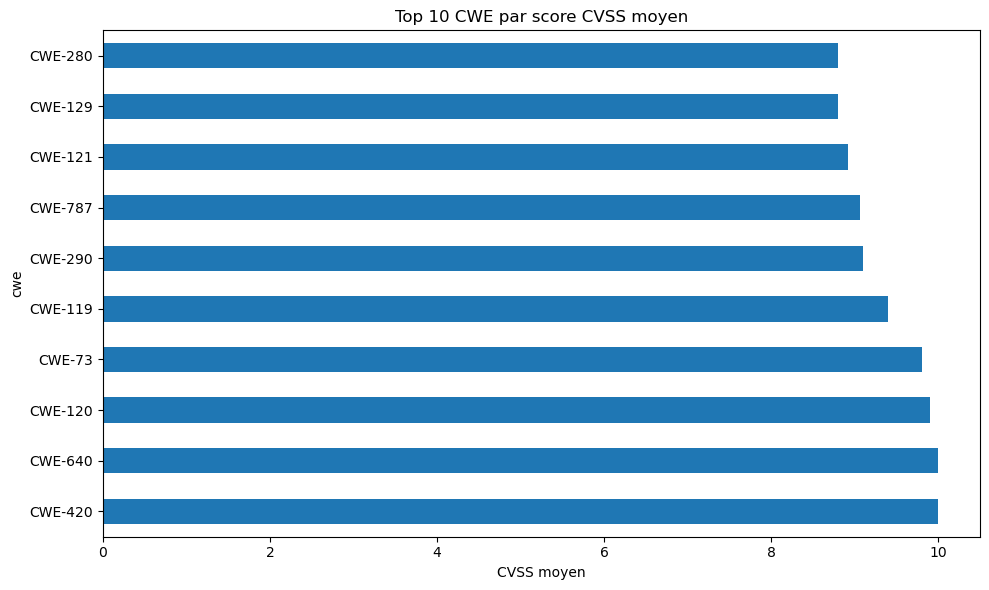

In [62]:
# Top 10 CWE par CVSS moyen 
df_cwe = df[df['cwe'].notna() & (df['cwe'] != 'Non disponible')]
plt.figure(figsize=(10, 6))
df_cwe.groupby('cwe')['cvss'].mean().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 CWE par score CVSS moyen')
plt.xlabel('CVSS moyen')
plt.tight_layout()
plt.show()

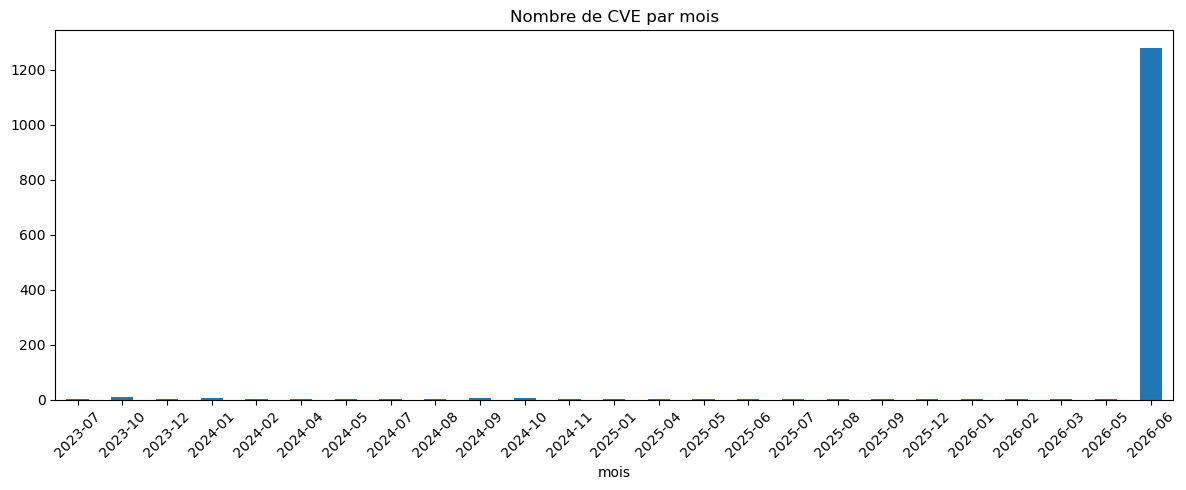

In [63]:
#  Nombre de CVE par mois
df['mois'] = df['date_publication'].dt.tz_localize(None).dt.to_period('M')
plt.figure(figsize=(12, 5))
df.groupby('mois').size().plot(kind='bar')
plt.title('Nombre de CVE par mois')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


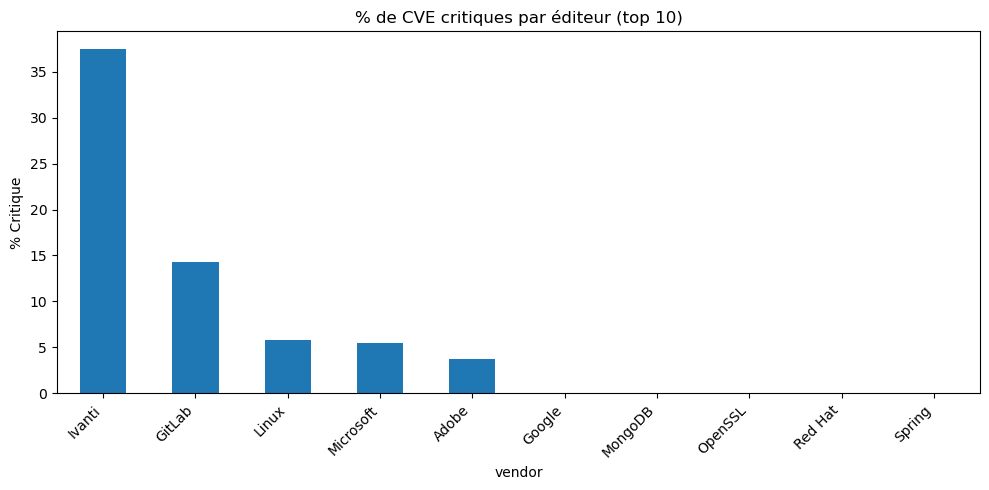

In [64]:
# % CVE critiques par éditeur 
top_ed2 = df['vendor'].value_counts().head(10).index
df_top2 = df[df['vendor'].isin(top_ed2)]
taux = df_top2.groupby('vendor').apply(
    lambda x: (x['base_severity'] == 'Critique').sum() / len(x) * 100,
    include_groups=False
).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
taux.plot(kind='bar')
plt.title('% de CVE critiques par éditeur (top 10)')
plt.ylabel('% Critique')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


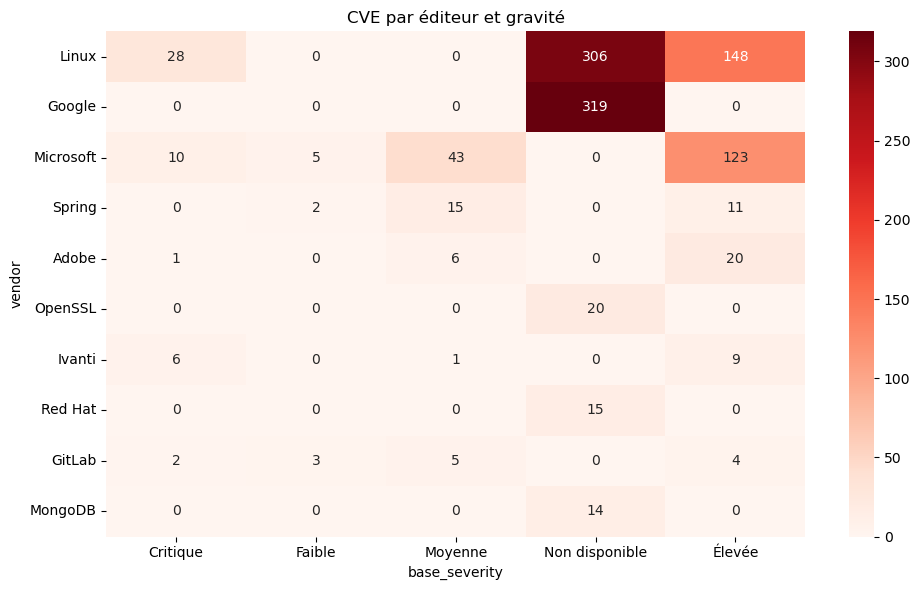

In [65]:
# Heatmap CVE par éditeur et gravité 
pivot = pd.crosstab(df['vendor'], df['base_severity'])
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).head(10).index]
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Reds')
plt.title('CVE par éditeur et gravité')
plt.tight_layout()
plt.show()

Partie 6 Modèle Machine Learning

In [37]:
print(df_final_consolide.columns.tolist())

['id_anssi', 'titre', 'type_bulletin', 'date_publication', 'cve', 'cvss', 'base_severity', 'cwe', 'cwe_description', 'epss', 'lien', 'description_cve', 'vendor', 'produit', 'versions_affectees']


6.1 Apprentissage non supervisé : KMeans.
Identifier automatiquement des groupes de vulnérabilités selon CVSS et EPSS

In [66]:
#preparation des données
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df_final_consolide[
    ["cvss", "epss"]
].copy()

X = X.fillna(0) #cas où cvss ou epss= NaN alors on remplacep ar 0

scaler = StandardScaler() #standardisation pr que les deux variables est le mm poids
X_scaled = scaler.fit_transform(X)

print("Données prêtes pour KMeans")

#test sur 5 premieres lignes
print(X.head())
print(X_scaled[:5])

Données prêtes pour KMeans
   cvss     epss
0   7.8  0.00356
1   7.4  0.00031
2   0.0  0.11841
3   0.0  0.00586
4   0.0  0.00057
[[ 1.25827808 -0.17539065]
 [ 1.15291856 -0.19715735]
 [-0.79623266  0.59381096]
 [-0.79623266 -0.15998652]
 [-0.79623266 -0.19541601]]


In [67]:
#création du modèle 
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)
#choix de 3 clusters a revoir par la suite
#Cluster 0:vulnérabilités peu risquées / Cluster 1:vulnérabilités moyennes / Cluster 2:vulnérabilités critiques

#ENTRAINEMENT
df_final_consolide["cluster"] = kmeans.fit_predict(
    X_scaled)

#verif 
print(
    df_final_consolide["cluster"]
    .value_counts()
)

#visualiser qlq ligne 
display(
    df_final_consolide[
        ["cve", "cvss", "epss", "cluster"]
    ].head(10)
)


cluster
0    811
2    490
1     43
Name: count, dtype: int64


,cve,cvss,epss,cluster
0,CVE-2026-20245,7.8,0.00356,2
1,CVE-2026-50752,7.4,0.00031,2
2,CVE-2026-50751,NaN,0.11841,0
3,CVE-2026-44963,NaN,0.00586,0
4,CVE-2026-8045,NaN,0.00057,0
5,CVE-2025-15467,NaN,0.02889,0
6,CVE-2026-24349,7.1,0.00005,2
7,CVE-2025-40808,6.1,0.00015,2
8,CVE-2026-44746,6.1,0.00093,2
9,CVE-2026-44750,4.3,0.00026,2


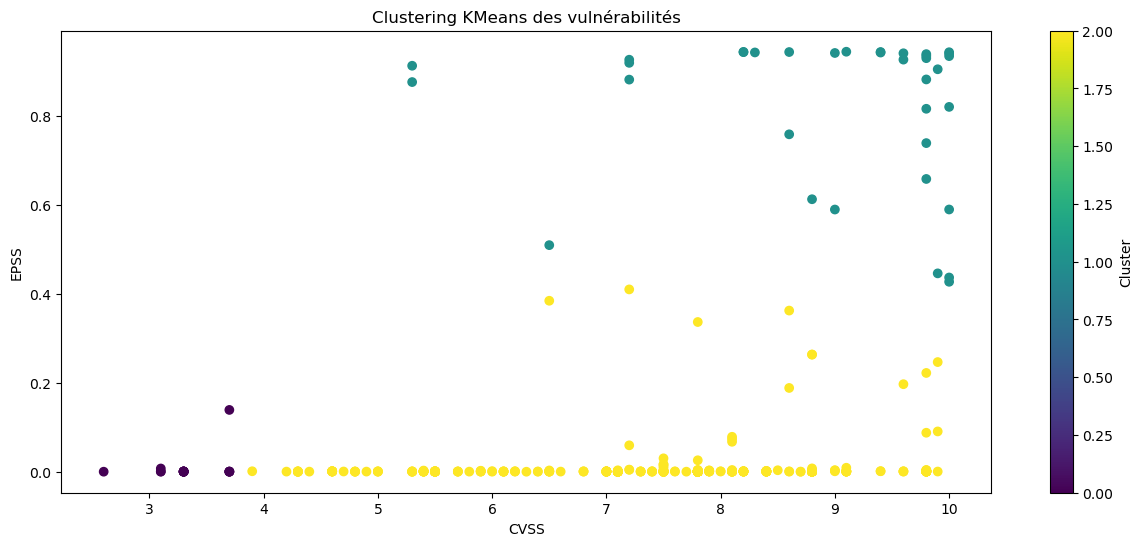

In [68]:
#visualisation des culters 
plt.figure(figsize=(15,6))

plt.scatter(
    df_final_consolide["cvss"],
    df_final_consolide["epss"],
    c=df_final_consolide["cluster"])

plt.xlabel("CVSS")
plt.ylabel("EPSS")
plt.title("Clustering KMeans des vulnérabilités")

plt.colorbar(label="Cluster")

plt.show()

In [ ]:
df_final_consolide.groupby("cluster")[
    ["cvss", "epss"]].mean()

,cvss,epss
cluster,,
0,3.338889,0.001217
1,8.940000,0.820735
2,7.530204,0.007689


In [ ]:
#evaluation du modele 
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    df_final_consolide["cluster"])

print("Silhouette Score :", round(silhouette, 4))

Silhouette Score : 0.8842


-> validation du modèle car 0.8842 tres bon score donc pas besoin de tester pour k=2 , k=4 ou k=5

6.2 Apprentissage supervisé :  
Nous avons choisi d'utiliser l'algorithme KNN. Ce choix a été motivé par le fait que KNN fait partie des méthodes étudiées dans le cours et qu'il est particulièrement adapté aux problèmes de classification.

L'objectif du modèle est de prédire le niveau de criticité d'une vulnérabilité (base_severity) à partir des scores CVSS et EPSS. Les vulnérabilités dont la criticité est "Non disponible" ont été retirées, car elles correspondent à une absence d'information et non à une classe réelle. Le modèle est ainsi entraîné sur les classes Faible, Moyenne, Élevée et Critique afin d'obtenir une classification plus pertinente.

In [81]:
#preparation des données 
df_ml = df_final_consolide[
    df_final_consolide["base_severity"] != "Non disponible"
].copy()

df_ml["cvss"] = pd.to_numeric(df_ml["cvss"], errors="coerce")
df_ml["epss"] = pd.to_numeric(df_ml["epss"], errors="coerce")

df_ml = df_ml.dropna(
    subset=["cvss", "epss", "base_severity"]
)

print(df_ml["base_severity"].value_counts())
print(df_ml[["cvss", "epss"]].isna().sum())

base_severity
Élevée      346
Moyenne     102
Critique     75
Faible       19
Name: count, dtype: int64
cvss    0
epss    0
dtype: int64


In [83]:
#encoder la variable cible
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_ml["severity_encoded"] = encoder.fit_transform(
    df_ml["base_severity"]
)

In [84]:
#verif 
for classe, code in zip(
    encoder.classes_,
    range(len(encoder.classes_))
):
    print(f"{classe} -> {code}")

Critique -> 0
Faible -> 1
Moyenne -> 2
Élevée -> 3


In [85]:
#train/test split (80% train , 20% test)
from sklearn.model_selection import train_test_split

X = df_ml[
    ["cvss", "epss"]
]

y = df_ml["severity_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (433, 2)
Test : (109, 2)


In [86]:
#standardisation 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[-1.81763176 -0.26333299]
 [ 0.03722415 -0.26338557]
 [ 0.42098745  0.14423968]
 [ 0.2291058  -0.2680123 ]
 [ 0.80475074 -0.26795972]]


In [87]:
#entrainement du modele
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

print("Modèle entraîné")


Modèle entraîné


In [90]:
#predictions
y_pred = knn.predict(
    X_test_scaled
)
#test
print(y_pred[:10])

[0 3 3 1 3 3 3 3 0 3]


In [89]:
#accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", round(accuracy, 4))

Accuracy : 0.9633


interprétation:Le modèle KNN obtient une accuracy de 96.33 % sur le jeu de test. Cela signifie que le modèle prédit correctement le niveau de criticité d'une vulnérabilité dans plus de 96 % des cas. Ce résultat montre que les variables retenues (CVSS et EPSS) permettent de discriminer efficacement les différents niveaux de gravité. Les performances élevées du modèle s'expliquent en partie par le fait que la variable cible (base_severity) est directement dérivée du score CVSS.


6.3 visualisation

[[12  0  0  0]
 [ 0  3  0  0]
 [ 0  0 11  3]
 [ 1  0  0 79]]


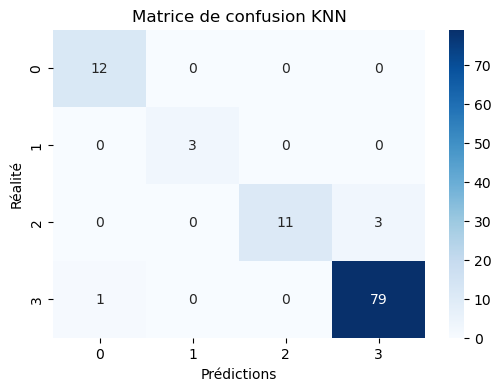

In [ ]:
#matrice de confusio,
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matrice de confusion KNN")

plt.xlabel("Prédictions")
plt.ylabel("Réalité")

plt.show()

In [92]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      1.00      1.00         3
           2       1.00      0.79      0.88        14
           3       0.96      0.99      0.98        80

    accuracy                           0.96       109
   macro avg       0.97      0.94      0.95       109
weighted avg       0.96      0.96      0.96       109

